**The Question:** If you know the count of neutrons at a given time in a reactor, are you able to determine what it will be in the future and what it was in the past?

To answer this, first we must understand neutron fission a little. Inside a piece of fissible material such as the uranium in a reactor core, neutrons slam into other nuclei splitting it apart. That split (called fission) not only releases a lot of energy, but it also releases additional neutrons that fly off and slam into other nuclei causing more fission. It becomes a chain reaction of neutrons making more neutrons. However, not every neutron is guarenteed to ensure more splitting. Some simply get absorbed back into nuclei while some leak out of the edges and become unusable and gone. So in each "round" of a reaction only a fraction of the neutrons will succedd in producing more. At its simplest, the behavior of this system can be captured by just looking at a single number called the multiplication factor k- the average number of next round neutrons that each neutron produces. From this we construct the simple equation $N_{n+1}=kN_n$ where $N_n$ is the amount of neutrons at the nth round. It can be seen that if k > 1 the population must grow over time, if k = 1 then it will remain constant, and if k < 1 then the population will decrease. Actually determining values for k is quite the ordeal by itself so we will just be manually entering common values but more information on how it can be calculated can be found here https://www.nuclear-power.com/nuclear-power/reactor-physics/nuclear-fission-chain-reaction/six-factor-formula-effective-multiplication-factor/neutron-life-cycle/.

**Assumptions** 
- Only track the amount of neutrons not the location. Doing this disregards the space itself and treats all the reactions as happening in a "point" but it keeps the thing we care about.
- k is staying constant for each run. In real reactions the value of k will vary and shift during the reaction as a whole but for our sake we will freeze k to see clean behavior.
- Time is measured in discrete generations. Rather than treating time as continous seconds we simply step the reaction forward one "step" where everything happens all at once.
- Neutrons act independently. Each neutron isn't effected by the state of other neutrons and acts as its own.

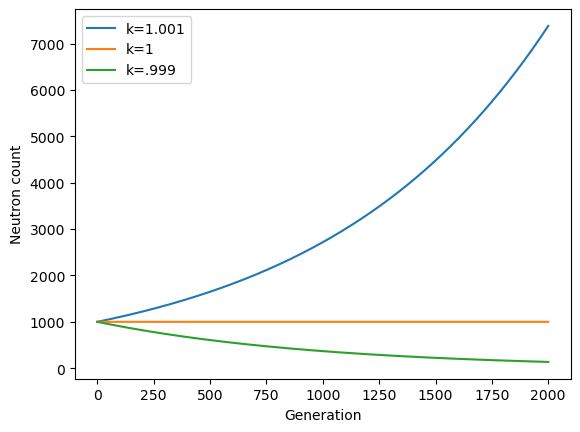

In [2]:
import numpy as np
import matplotlib.pyplot as plt
def growd(N0,k,n): #Fisrt we create a simple function that takes in a inital neutron count and outputs the future count for n generations using the k value
    N=[N0]
    for i in range(n):
        N.append(k*N[-1])
    return N

#Initiliaze
N0=1000
n=2000
gen=np.arange(n+1)

#Then we'll run and plot for three different k values to capture each behavior
N1=growd(N0,1.001,n)
N2=growd(N0,1,n)
N3=growd(N0,.999,n)
plt.plot(gen,N1,label="k=1.001")
plt.plot(gen,N2,label="k=1")
plt.plot(gen,N3,label="k=.999")
plt.legend()
plt.xlabel("Generation")
plt.ylabel("Neutron count")
plt.show()

So using this framework are we able to answer our question? Well as long as k stays constant and I'm given the value of the population at any generation then yes, I am able to determine the population at any generation since all it's doing is moving forward or backward by powers of k.

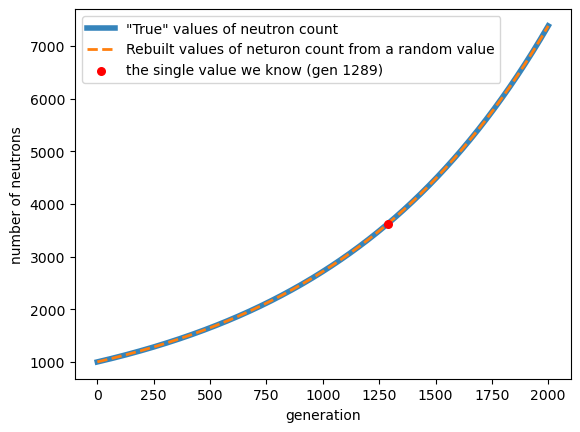

In [3]:
#True population initally constructed
k=1.001
N0=1000
n=2000
gen=np.arange(n+1)
trueN=growd(N0,k,n)

#Now imagine we were only given the count at a generation
gk=np.random.randint(500, n-500)  
Nk=trueN[gk]

#Then we can simply rebuild our values by raising it to powers of k negative and postive
rebuilt=Nk*k**(gen-gk)

#Now plot and compare
plt.plot(gen,trueN,label='"True" values of neutron count',alpha=.9,lw=4)
plt.plot(gen,rebuilt,label="Rebuilt values of neturon count from a random value",ls="--",lw=2)
plt.scatter([gk], [Nk],color="red",zorder=8,s=30,label=f"the single value we know (gen {gk})")
plt.xlabel("generation")
plt.ylabel("number of neutrons")
plt.legend()
plt.show()

So clearly from our assumptions using this model yes we are able to predict future and past generations of neutron count what felt quite easily. Where things get more complicated is if we now disregard the idea of neturon count being a continous smooth number but rather a discrete number.

The smooth model has the inherent assumption that the neutron count is a large enough number to where it basically behaves continously where I can simply multiply by k to recieve a whole number. The caveat is that neutrons are physically discrete countable things and it doesn't make physica sense to have one neutron split into 1.02 neutrons. In reality, a neutron either collides and produces a few neutrons or it gets absorbed and is taken out of count. When the population is large enough then yes these coin flips average out nicely to our model above but what if it's smaller?

This time instead of just multiplying the whole population by k we will treat each neutron individually and each neutron will produce a random amount of offspring that averages to our value of k. This type of approach is called a branching process https://en.wikipedia.org/wiki/Branching_process.

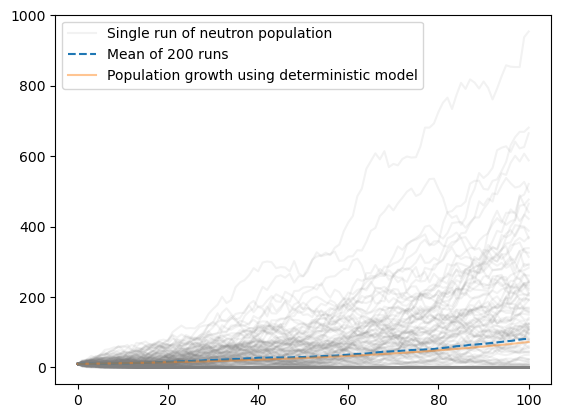

In [4]:
rng=np.random.default_rng() #
def grows(N0,k,n,rng):
    N=[N0]
    for i in range(n):
        N.append(rng.poisson(k*N[i]))
    return N
N0=10
k=1.02
n=100
trials=200
gen=np.arange(n+1)
runs=np.zeros((trials,n+1))
for i in range(trials):
    runs[i]=grows(N0,k,n,rng)
    plt.plot(gen,runs[i],alpha=.1,color="gray")
plt.plot(gen,runs[-1],alpha=.1,color="gray",label="Single run of neutron population")
N=runs.mean(axis=0)
plt.plot(gen,N,label=f"Mean of {trials} runs",ls="--")
Nt=growd(N0,k,n)
plt.plot(gen,Nt,alpha=.45,label="Population growth using deterministic model")
plt.legend()
plt.show()

Taking a statistical approach:

In [17]:
gen20 = []
for i in range(trials):
    if int(runs[i][20]) != 0:
        gen20.append(int(runs[i][20]))

gen40 = []
for i in range(trials):
    if int(runs[i][40]) != 0:
        gen40.append(int(runs[i][40]))

gen60 = []
for i in range(trials):
    if int(runs[i][60]) != 0:
        gen60.append(int(runs[i][60]))

gen80 = []
for i in range(trials):
    if int(runs[i][80]) != 0:
        gen80.append(int(runs[i][80]))

endvalue = []
for i in range(trials):
    if int(runs[i][100]) != 0:
        endvalue.append(int(runs[i][100]))


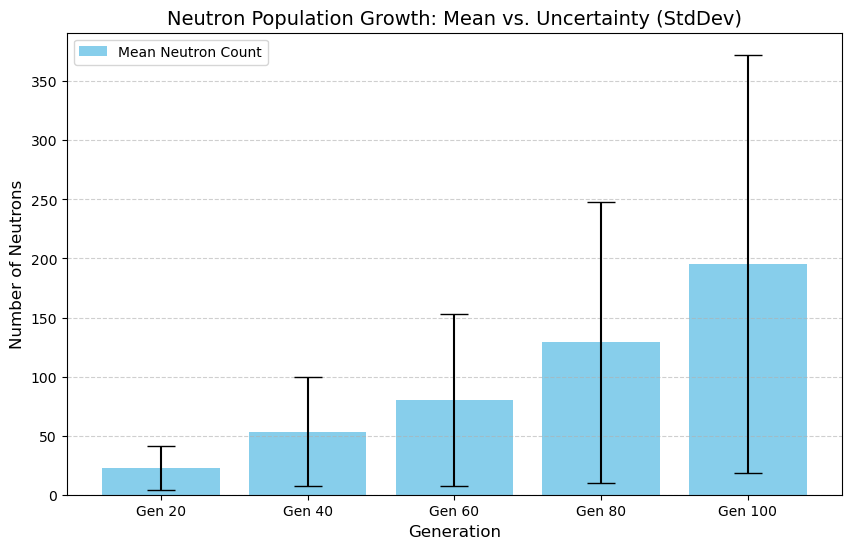

In [24]:
labels = df_stats['Generation']
means = df_stats['Mean']
std_devs = df_stats['StdDev']

plt.figure(figsize=(10, 6))


plt.bar(labels, means, yerr=std_devs, capsize = 10, color='skyblue', label='Mean Neutron Count')

plt.xlabel('Generation', fontsize=12)
plt.ylabel('Number of Neutrons', fontsize=12)
plt.title('Neutron Population Growth: Mean vs. Uncertainty (StdDev)', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

plt.show()

In [19]:
data_map = { 
    "Gen 20": gen20,
    "Gen 40": gen40,
    "Gen 60": gen60,
    "Gen 80": gen80,
    "Gen 100": endvalue
}

rows = []

for label, data in data_map.items():
    avg = statistics.mean(data)
    sd = statistics.stdev(data)
    
    rows.append({
        "Generation": label,
        "Mean": round(avg, 2),
        "Median": statistics.median(data),
        "StdDev": round(sd, 2),
        "+2 SD": round(avg + 2*sd, 2),
        "-2 SD": round(avg - 2*sd, 2)
    })
    
df_stats = pd.DataFrame(rows)

df_stats

,Generation,Mean,Median,StdDev,+2 SD,-2 SD
0,Gen 20,22.45,16.0,18.52,59.49,-14.59
1,Gen 40,53.49,43.0,46.32,146.13,-39.16
2,Gen 60,80.01,60.0,72.59,225.19,-65.17
3,Gen 80,129.06,88.5,119.10,367.27,-109.15
4,Gen 100,195.36,141.0,177.12,549.59,-158.87


While we can predict an expected average for the future, the high standard deviation relative to the mean proves that the process is lossy. The random fluctuations at each generation accumulate, creating a wide range of possible outcomes. Therefore, working backward to find a unique initial condition is impossible because the current state could have evolved from a vast variety of different past states.